In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from model_pipelines.rf_classifier import *
from model_pipelines.check_calibration import *
from model_pipelines.auxilliary_functions import *
from eda.scoring_function import score_model_optimal_k
from sklearn.model_selection import train_test_split
import joblib
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

In [11]:
PROJECT_FOLDER_NAME = "-Cost-Sensitive-Predictive-Modeling"
current_path = Path(os.getcwd()).resolve()
project_root = Path(*current_path.parts[:current_path.parts.index(PROJECT_FOLDER_NAME) + 1])
#======== run variables ======================================
EXP_NAME = "rf_xgb_selected" # set run name
EXP_DIR = project_root / "experiment_results" / EXP_NAME
EXP_DIR.mkdir(parents=True, exist_ok=True)
#filenames to save output
FILE_SUBSETS_RESULTS_DF= EXP_DIR / "all_subsets_results_before_tuning.csv"
FILE_ALL_SUBSETS_DICT= EXP_DIR / "all_subsets_dict.json"
FILE_BEST_AFTER_TUNING = EXP_DIR / "top10_subsets_hyperparam_tuning_dict.json"
FILE_MULTI_RUN_TOP10_SUBSETS_RESULTS= EXP_DIR / "top10_subsets_mulitrun_check_dict.json"
FILE_CV_TOP10_SUBSETS_RESULTS= EXP_DIR / "top10_subsets_cv_dict.json"
PLOT_DIR = EXP_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
# Check of directories
print(f" Root: {project_root}")
print(EXP_DIR)

 Root: C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling
C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\experiment_results\rf_xgb_selected


In [3]:
y=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\y_train.txt")
x=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_train.txt",sep=" ")
selected_cols_dict=joblib.load("C:\\Users\\andrz\\Downloads\\selected_features_dictionary.joblib")


In [12]:
selected_second_level_subset=unpack_model_feature_dict(selected_cols_dict,'xgb',extract='common') # for selecting the features found by all xgb (or possibly rf - change second argument) models, extract works as in the previous example
print(selected_second_level_subset)

['V191', 'V255', 'V176', 'V380', 'V160', 'V342', 'V215']


In [13]:
x_t,x_tst,y_t,y_tst=train_test_split(x.loc[:,selected_second_level_subset],y,test_size=0.2,random_state=7)

subset 0 finished
subset 1 finished
subset 2 finished
subset 3 finished
subset 4 finished
subset 5 finished
subset 6 finished
subset 7 finished
subset 8 finished
subset 9 finished
subset 10 finished
subset 11 finished
subset 12 finished
subset 13 finished
subset 14 finished
subset 15 finished
subset 16 finished
subset 17 finished
subset 18 finished
subset 19 finished
subset 20 finished
subset 21 finished
subset 22 finished
subset 23 finished
subset 24 finished
subset 25 finished
subset 26 finished
subset 27 finished
subset 28 finished
subset 29 finished
subset 30 finished
subset 31 finished
subset 32 finished
subset 33 finished
subset 34 finished
subset 35 finished
subset 36 finished
subset 37 finished
subset 38 finished
subset 39 finished
subset 40 finished
subset 41 finished
subset 42 finished
subset 43 finished
subset 44 finished
subset 45 finished
subset 46 finished
subset 47 finished
subset 48 finished
subset 49 finished
subset 50 finished
subset 51 finished
subset 52 finished
sub

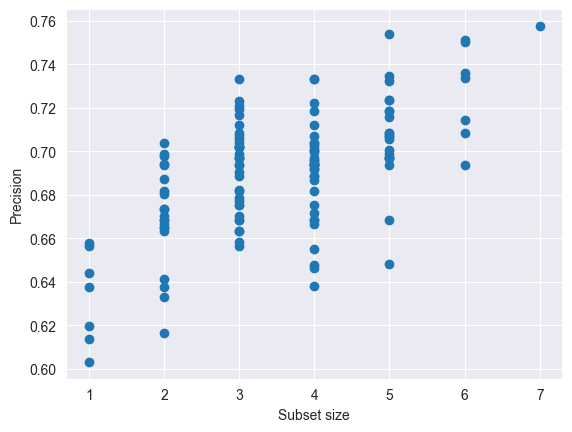

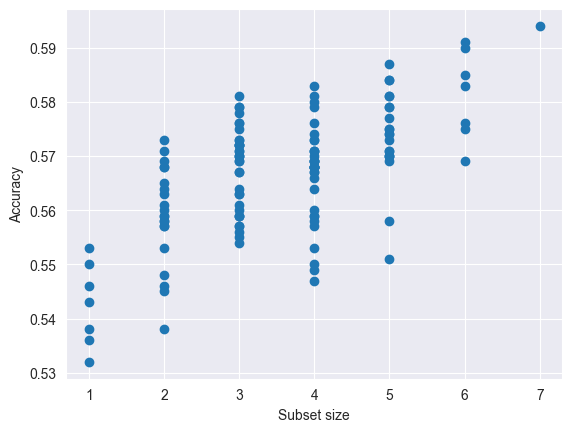

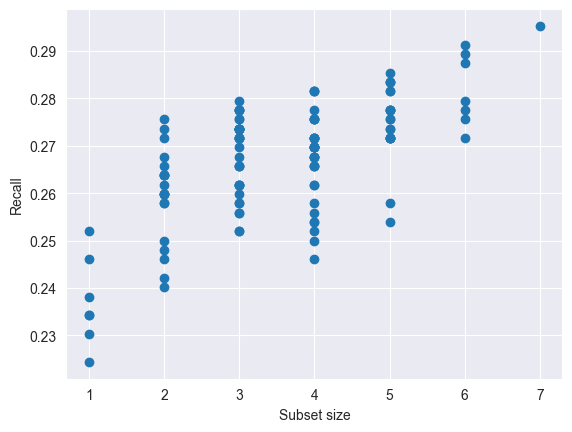

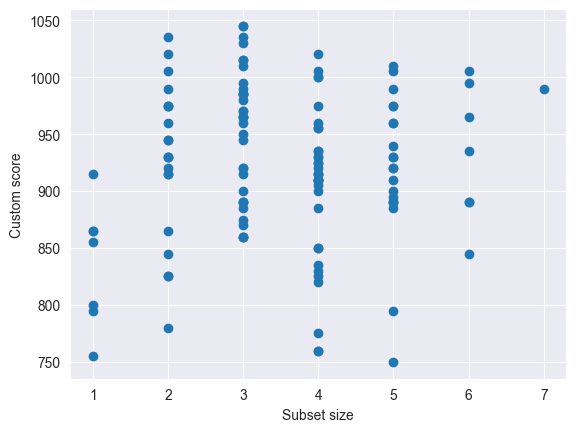

In [14]:
best_model,best_ft,df,all_subsets=train_model_all_combinations(x_t,y_t,x_tst,y_tst,max_subset=selected_second_level_subset,return_metrics=True)

In [15]:
df=df.sort_values(by="Precision", ascending=False)
df_top10_prec=df.head(10)

print(df_top10_prec)

              Custom Score  Precision  Accuracy    Recall
Subset index                                             
126                  990.0   0.757576     0.594  0.295276
54                   990.0   0.754011     0.587  0.277559
62                  1005.0   0.751269     0.591  0.291339
94                   995.0   0.750000     0.590  0.289370
110                  935.0   0.735751     0.583  0.279528
78                  1010.0   0.734694     0.584  0.283465
118                  965.0   0.733668     0.585  0.287402
38                  1020.0   0.733333     0.583  0.281496
14                  1000.0   0.732984     0.581  0.275591
6                   1035.0   0.732984     0.581  0.275591


In [16]:
df.to_csv(FILE_SUBSETS_RESULTS_DF, index=True)
save_dict_to_json(all_subsets,FILE_ALL_SUBSETS_DICT)


Successfully saved data to C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\experiment_results\rf_xgb_selected\all_subsets_dict.json


In [17]:
top10_hyperparameter_tuning_result_dict = {
    idx: {}
    for idx in df_top10_prec.index
}

In [ ]:
for ind in df_top10_prec.index:
    print("=========================================")
    print(f"subset {ind}: {all_subsets[ind]}")
    print("=========================================")
    best_c_hyperparams,best_p_hyperparams=final_rf_hyperparameter_grid_optimizer(x_t.loc[:,all_subsets[ind]],y_t,x_tst.loc[:,all_subsets[ind]],y_tst)
    rf=RandomForestClassifier(max_depth=best_c_hyperparams['max_depth'], n_estimators=best_c_hyperparams['n_estimators'],
                               random_state=7)
    rf.fit(x_t.loc[:,all_subsets[ind]],y_t)
    y_pred_proba=rf.predict_proba(x_tst.loc[:,all_subsets[ind]])[:,1]
    best_score,best_threshold, best_k, best_fp, best_tp=score_model_optimal_k(y_tst,y_pred_proba,len(all_subsets[ind]),keep_fp_tp=True,max_k=200,feature_penalty=40)
    top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']=best_c_hyperparams
    top10_hyperparameter_tuning_result_dict[ind]['best_p_hyperparams']=best_p_hyperparams
    top10_hyperparameter_tuning_result_dict[ind]['best_threshold']=best_threshold
    top10_hyperparameter_tuning_result_dict[ind]['best_score']=best_score
    top10_hyperparameter_tuning_result_dict[ind]['best_fp']=best_fp
    top10_hyperparameter_tuning_result_dict[ind]['best_tp']=best_tp
    top10_hyperparameter_tuning_result_dict[ind]['subset_list']=all_subsets[ind] # added for easier reloading
    print("=======================================")
    print(f"Score for subset {all_subsets[ind]}")
    print(f"best score: {best_score}, best threshold: {best_threshold}, fp:{best_fp}, tp:{best_tp}")
    print(f"best custom hyperparameters: {best_c_hyperparams}")
    print(f"best precision hyperparameters: {best_p_hyperparams}")
    print("=======================================")
save_dict_to_json(top10_hyperparameter_tuning_result_dict,FILE_BEST_AFTER_TUNING)

subset 126: ['V191', 'V255', 'V176', 'V380', 'V160', 'V342', 'V215']
Score for subset ['V191', 'V255', 'V176', 'V380', 'V160', 'V342', 'V215']
best score: 960, best threshold: 0.5401197215403015, fp:50, tp:149
best custom hyperparameters: {'max_depth': 2, 'n_estimators': 1000}
best precision hyperparameters: {'max_depth': 2, 'n_estimators': 1000}
subset 54: ['V191', 'V255', 'V176', 'V160', 'V342']
Score for subset ['V191', 'V255', 'V176', 'V160', 'V342']
best score: 1030, best threshold: 0.5454362237662115, fp:48, tp:147
best custom hyperparameters: {'max_depth': 2, 'n_estimators': 500}
best precision hyperparameters: {'max_depth': 2, 'n_estimators': 500}
subset 62: ['V191', 'V255', 'V176', 'V380', 'V160', 'V342']
Score for subset ['V191', 'V255', 'V176', 'V380', 'V160', 'V342']
best score: 1010, best threshold: 0.564745148713317, fp:50, tp:150
best custom hyperparameters: {'max_depth': 3, 'n_estimators': 500}
best precision hyperparameters: {'max_depth': 3, 'n_estimators': 500}
subset